In [222]:
# speed_kmh 주행속도,
# payload_kg,탑승자 및 화물 하중
# ambient_temp_C,외부 기온
# hvac_power_kw,냉난방 사용 전력
# road_grade_pct, 도로 경사도
# battery_temp_C,배터리 온도
# driving_style_index,
# tire_pressure_bar,겨울철 기온 강하로 인한 타이어 공기압 저하 영향
# trip_distance_km, 주행거리(도착지까지의 총 잔여 필요 전력 계산에 사용)

 # < 타겟변수 >
# energy_consumption_kwhper100km (타깃 변수 : 100km당 소비 전력량) 

In [223]:
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

import platform
from matplotlib import rc


if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('MacOS system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False


MacOS system... font set to NanumGothic


In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [225]:
df = pd.read_csv('data/ev_energy_consumption.csv')
df

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883
...,...,...,...,...,...,...,...,...,...,...
7995,50.0,3.8,35.7,2.79,4.80,32.3,0.986,2.11,172.4,23.931
7996,43.0,286.3,11.4,4.20,4.94,17.3,0.643,2.54,130.4,26.811
7997,70.1,358.6,8.9,3.81,-1.50,30.5,0.709,2.16,166.6,26.102
7998,119.9,372.5,1.6,0.59,0.65,17.6,0.757,2.28,172.8,28.355


In [226]:
# 데이터 구조 결측치 확인
df.shape

(8000, 10)

In [227]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [228]:
# 결측치 확인
df.isna().sum()

speed_kmh                         0
payload_kg                        0
ambient_temp_C                    0
hvac_power_kw                     0
road_grade_pct                    0
battery_temp_C                    0
driving_style_index               0
tire_pressure_bar                 0
trip_distance_km                  0
energy_consumption_kwhper100km    0
dtype: int64


=== 핵심 제어 인자와 전비 간의 상관계수 ===
road_grade_pct    0.504623
payload_kg        0.468906
speed_kmh         0.448316
hvac_power_kw     0.369619
Name: energy_consumption_kwhper100km, dtype: float64


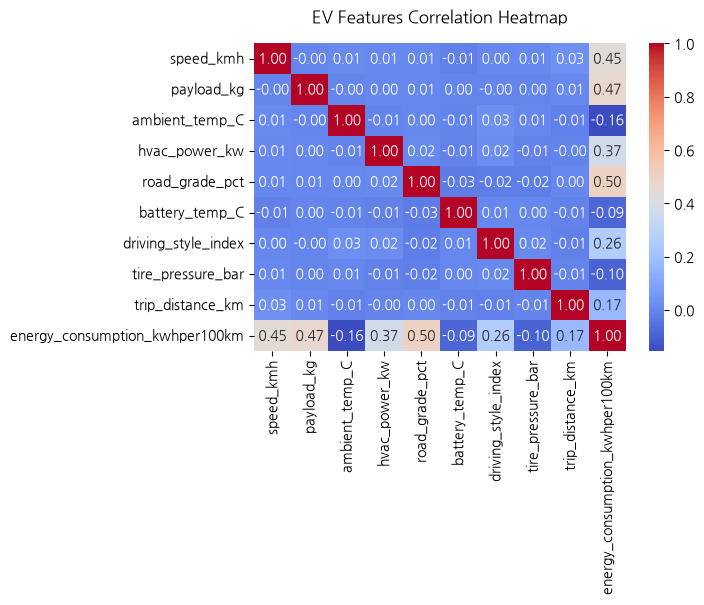

In [229]:
# 상관계수 행렬 연산
corr_matrix = df.corr()

# 주요 4대 영향 인자의 전비 상관계수 별도 출력
target_col = 'energy_consumption_kwhper100km'

key_features = ['speed_kmh', 'payload_kg', 'road_grade_pct', 'hvac_power_kw']
print("\n=== 핵심 제어 인자와 전비 간의 상관계수 ===")
print(corr_matrix[target_col][key_features].sort_values(ascending=False)) #[cite: 2]

# 상관관계 히트맵 시각화
plt.figure(figsize=(6, 4))
sb.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True
) 

plt.title('EV Features Correlation Heatmap', pad=15)
plt.show()

## 데이터 분할


In [230]:
# 1. 특성(X)과 타깃(y) 분리
X = df.drop(['energy_consumption_kwhper100km'], axis =1)

In [231]:
X.shape

(8000, 9)

In [232]:
# 100km당 전비 (연속형 수치)
y = df['energy_consumption_kwhper100km']   

In [233]:
y.shape

(8000,)

In [234]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


feature들이 모두 수치형 데이터이고, 결측치도 없기 때문에 scaling이 필요하지 않다.

In [235]:
from sklearn.model_selection import train_test_split

# X_train, y_train : 회귀모델이 가중치를 학습하는 훈련용 데이터
# X_test, y_test : 학습된 회귀모델이 예측 성능을 검증하는 테스트용 데이터

# 2. 학습용(Train)과 검증용(Test) 데이터 분할 (8:2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 전체 8,000개 중 20%(1,600개)를 테스트용으로 분할
    random_state=42      # 언제 실행해도 동일하게 나뉘도록 난수 시드 고정
)

In [236]:
print(f"학습용 X: {X_train.shape}, 학습용 y: {y_train.shape}")
print(f"검증용 X: {X_test.shape},  검증용 y: {y_test.shape}")

학습용 X: (6400, 9), 학습용 y: (6400,)
검증용 X: (1600, 9),  검증용 y: (1600,)


- 전비 예측 엔진 확보 : 추천 엔진의 핵심인 알파 가중치 목적 함수를 계산하려면 속도와 외생조건에 따른 전력 소비량을 산출해줄 신뢰할 수 있는 회귀모델이 먼저 완성되어야 함.

- 선형회귀의 회귀계수(coef)와 트리의 피처 중요도를 통해 속도/경사도/공조 등이 전치에 미치는 실제 물리적 영향력을 수치로 증명할 수 있다.

- 추천 오차 최소화 :  여러 알고리즘을 개별 평가하여 가장 예측 오차가 작고 일반화 성능이 우수한 최종 모델 선정

### LinearRegression

In [237]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. 선형 회귀 모델 생성
lr_reg = LinearRegression()

# 학습
lr_reg.fit(X_train, y_train)

# 예측
lr_test_pred = lr_reg.predict(X_test)

print("=== [1. Linear Regression 성능 평가] ===")
print(f"R² Score  : {r2_score(y_test, lr_test_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, lr_test_pred)):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, lr_test_pred):.4f} ")


=== [1. Linear Regression 성능 평가] ===
R² Score  : 0.9246
RMSE      : 1.0093
MAE       : 0.8107 


### LGBMRegressor
- 기본 성능이 LightGBM은 기본 설정(n_estimators=100, learning_rate=0.1, num_leaves=31 등) 자체가 매우 균형 있게 잡혀 있어, 튜닝 전에도 높은 예측력을 보여주기 때문에 튜닝 생략 ..

In [238]:
from lightgbm import LGBMRegressor

# 1. LightGBM 회귀 모델 생성 및 학습
lgb_reg = LGBMRegressor()
lgb_reg.fit(X_train, y_train)

# 2. 예측 수행
lgb_train_pred = lgb_reg.predict(X_train)
lgb_test_pred = lgb_reg.predict(X_test)

# 3. 성능 평가 지표 출력
print("=== [4. LightGBM Regressor 평가] ===")
print(f"R² Score  : {r2_score(y_test, lgb_test_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, lgb_test_pred)):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, lgb_test_pred):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2091
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 9
[LightGBM] [Info] Start training from score 24.164264
=== [4. LightGBM Regressor 평가] ===
R² Score  : 0.9371
RMSE      : 0.9216
MAE       : 0.7337


#### RandomForest + RandomizedSearchCV 

In [239]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# 기본 모델 생성
rf_reg = RandomForestRegressor(
    random_state = 2024,
    n_jobs=-1
)

# RandomForest 하이퍼파라미터 탐색 공간
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.8, 1.0]
}

# Randomized Search 
rf_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=rf_params,
    n_iter=30,  # 탐색할 하이퍼파라미터 조합 수
    scoring='neg_mean_squared_error',  # 평가 지표
    cv=5,  # 5-fold 교차 검증
    verbose=1,
    random_state=2024,
    n_jobs=-1
)

# 학습
rf_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터로 모델 재생성
rf_reg = rf_search.best_estimator_

# 평가
rf_pred = rf_reg.predict(X_test)

# 확인
print("=== [RandomForest 튜닝 결과] ===")
print("Best Params:", rf_search.best_params_)
print(f"R² Score : {r2_score(y_test, rf_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
=== [RandomForest 튜닝 결과] ===
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 15}
R² Score : 0.8989
MAE      : 0.9340
RMSE     : 1.1686


In [240]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print(rf_importance)

               Feature  Importance
4       road_grade_pct    0.258324
1           payload_kg    0.230762
0            speed_kmh    0.202559
3        hvac_power_kw    0.130154
6  driving_style_index    0.075024
2       ambient_temp_C    0.048679
8     trip_distance_km    0.026863
7    tire_pressure_bar    0.014212
5       battery_temp_C    0.013422


In [241]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# 기본 모델 생성
xgb_reg = XGBRegressor(
    random_state = 2024,
    n_jobs=-1
)

# XGBRegressor 하이퍼파라미터 탐색 공간
xgb_params = {
    'n_estimators': [100, 200, 300],          # 트리 개수 (학습 반복 횟수)
    'max_depth': [3, 5, 7, 9],                 # 개별 트리의 최대 깊이
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # 이전 트리의 오차 반영 비율 (학습률)
    'subsample': [0.7, 0.8, 1.0],              # 매 트리 학습 시 데이터 샘플링 비율
    'colsample_bytree': [0.7, 0.8, 1.0]        # 매 트리 학습 시 피처(컬럼) 샘플링 비율
}

# Randomized Search 
xgb_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=xgb_params,
    n_iter=30,  # 탐색할 하이퍼파라미터 조합 수
    scoring='neg_mean_squared_error',  # 평가 지표
    cv=5,  # 5-fold 교차 검증
    verbose=1,
    random_state=2024,
    n_jobs=-1
)

# 학습
xgb_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터로 모델 재생성
xgb_reg = xgb_search.best_estimator_

# 평가
xgb_pred = xgb_reg.predict(X_test)

# 확인
print("=== [XGBoost 튜닝 결과] ===")
print("Best Params:", xgb_search.best_params_)
print(f"R² Score : {r2_score(y_test, xgb_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, xgb_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
=== [XGBoost 튜닝 결과] ===
Best Params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
R² Score : 0.9435
MAE      : 0.6984
RMSE     : 0.8741


In [242]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_reg.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print(xgb_importance)

               Feature  Importance
4       road_grade_pct    0.251644
1           payload_kg    0.207814
0            speed_kmh    0.205049
3        hvac_power_kw    0.128936
6  driving_style_index    0.081505
2       ambient_temp_C    0.058178
8     trip_distance_km    0.035918
7    tire_pressure_bar    0.019204
5       battery_temp_C    0.011750


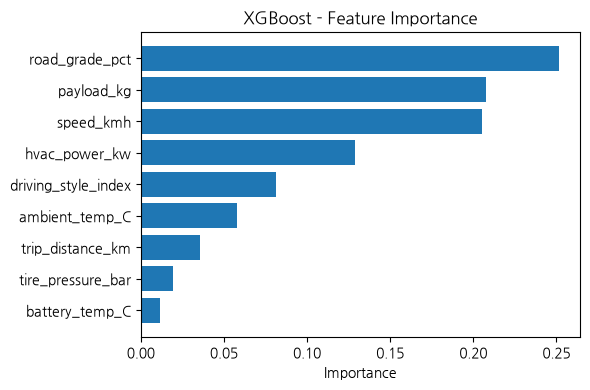

In [243]:
import matplotlib.pyplot as plt
plot_df = xgb_importance.sort_values(by='Importance', ascending=True)

# 2. 수평 막대그래프 시각화
plt.figure(figsize=(6, 4))
plt.barh(plot_df['Feature'], plot_df['Importance'])
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

#### 모델 간 피처 중요도 비교

중요도는 모델마다 계산 방식이 다르므로, **서로 다른 모델이 같은 순위를 내는지** 확인해야
"모델이 물리적으로 타당한 관계를 학습했다"고 말할 수 있다.
EDA 단계의 상관계수 순위와도 대조한다.


=== [피처 중요도 비교 : XGBoost vs 상관계수] ===


,Feature,XGBoost,|상관계수|,XGB 순위,상관 순위
0,road_grade_pct,0.2516,0.5046,1,1
1,payload_kg,0.2078,0.4689,2,2
2,speed_kmh,0.2050,0.4483,3,3
3,hvac_power_kw,0.1289,0.3696,4,4
4,driving_style_index,0.0815,0.2584,5,5
5,ambient_temp_C,0.0582,0.1555,6,7
6,trip_distance_km,0.0359,0.1720,7,6
7,tire_pressure_bar,0.0192,0.0951,8,8
8,battery_temp_C,0.0118,0.0869,9,9


findfont: Failed to find font weight bold, now using 600.


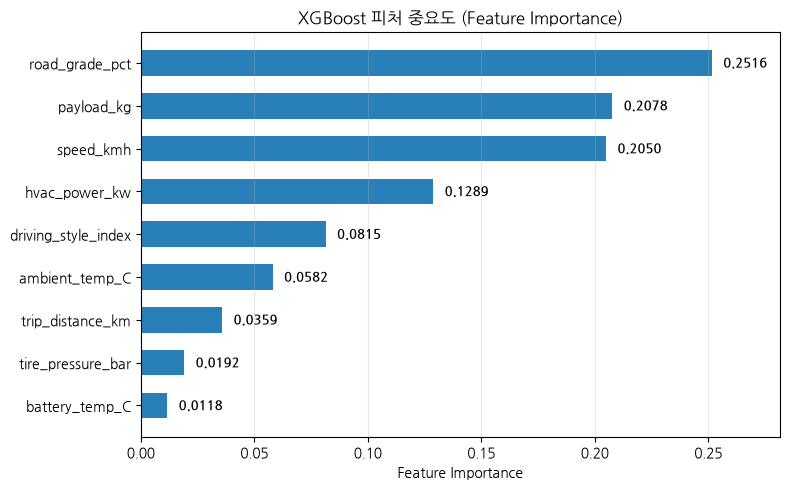

In [260]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. XGBoost 피처 중요도 데이터프레임 생성 및 정렬
importance_df = (
    xgb_importance.copy()
    .rename(columns={'Importance': 'XGBoost'})
    .sort_values('XGBoost', ascending=False)
    .reset_index(drop=True)
)

# EDA 상관계수(절댓값) 순위를 함께 붙여 비교
target_col = 'energy_consumption_kwhper100km'
importance_df['|상관계수|'] = importance_df['Feature'].map(
    df.corr()[target_col].abs()
)
importance_df['XGB 순위'] = importance_df['XGBoost'].rank(ascending=False).astype(int)
importance_df['상관 순위'] = importance_df['|상관계수|'].rank(ascending=False).astype(int)

print("=== [피처 중요도 비교 : XGBoost vs 상관계수] ===")
display(importance_df.round(4))

# 2. XGBoost 단독 수평 막대그래프 시각화
plot_df = importance_df.sort_values('XGBoost', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(plot_df['Feature'], plot_df['XGBoost'], color='#2980b9', height=0.6)

# 막대 끝에 중요도 수치 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2, f'{width:.4f}', 
             va='center', ha='left', fontsize=9, fontweight='bold')

plt.xlabel('Feature Importance')
plt.title('XGBoost 피처 중요도 (Feature Importance)')
plt.xlim(0, max(plot_df['XGBoost']) + 0.03)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [246]:
# 4개 개별 모델 평가 결과 정리
eval_table = pd.DataFrame([
    {
        'Model': 'Linear Regression',
        'Test R²': r2_score(y_test, lr_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, lr_test_pred)),
        'Test MAE': mean_absolute_error(y_test, lr_test_pred)
    },
    {
        'Model': 'Random Forest',
        'Test R²': r2_score(y_test, rf_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
        'Test MAE': mean_absolute_error(y_test, rf_pred)
    },
    {
        'Model': 'XGBoost',
        'Test R²': r2_score(y_test, xgb_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
        'Test MAE': mean_absolute_error(y_test, xgb_pred)
    },
    {
        'Model': 'LightGBM',
        'Test R²': r2_score(y_test, lgb_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, lgb_test_pred)),
        'Test MAE': mean_absolute_error(y_test, lgb_test_pred)
    }
]).round(4)

print("=== [ 4개의 회귀 모델 성능 벤치마크 결과] ===")
display(eval_table.sort_values(by='Test R²', ascending=False))

=== [ 4개의 회귀 모델 성능 벤치마크 결과] ===


,Model,Test R²,Test RMSE,Test MAE
2,XGBoost,0.9435,0.8741,0.6984
3,LightGBM,0.9371,0.9216,0.7337
0,Linear Regression,0.9246,1.0093,0.8107
1,Random Forest,0.8989,1.1686,0.9340


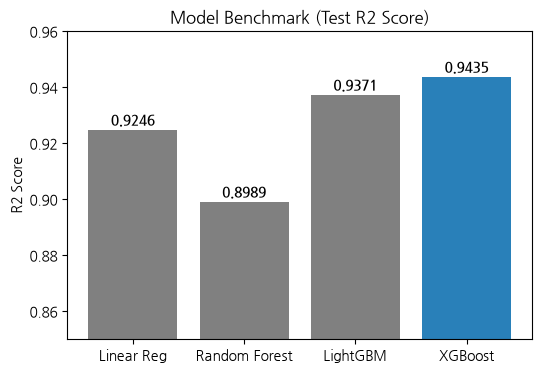

In [247]:
import matplotlib.pyplot as plt

# 1. 모델별 Test R2 점수 정의
models = ['Linear Reg', 'Random Forest', 'LightGBM', 'XGBoost']
r2_scores = [0.9246, 0.8989, 0.9371, 0.9435]

# 2. 막대그래프 시각화
plt.figure(figsize=(6, 4))
plt.bar(models, r2_scores, color=['gray', 'gray', 'gray', '#2980b9'])
plt.ylim(0.85, 0.96)
plt.title('Model Benchmark (Test R2 Score)')
plt.ylabel('R2 Score')

# 막대 위에 수치 표기
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

### XGBoost 모델 최적

#### 최적 속도 구하는 함수 

In [250]:
def predict_speed_profile(
    model,
    distance,
    road_grade,
    payload,
    ambient_temp,
    hvac_power,
    battery_temp,
    driving_style,
    tire_pressure
):
    speeds = np.arange(20, 131, 1)

    results = []

    for speed in speeds:

        X_input = pd.DataFrame([{
            'speed_kmh': speed,
            'payload_kg': payload,
            'ambient_temp_C': ambient_temp,
            'hvac_power_kw': hvac_power,
            'road_grade_pct': road_grade,
            'battery_temp_C': battery_temp,
            'driving_style_index': driving_style,
            'tire_pressure_bar': tire_pressure,
            'trip_distance_km': distance
        }])

        # kWh / 100 km
        consumption = model.predict(X_input)[0]

        # 전체 거리 소비 에너지
        total_energy = consumption * distance / 100

        # 주행 시간(hour)
        travel_time = distance / speed

        results.append([
            speed,
            consumption,
            total_energy,
            travel_time
        ])

    result = pd.DataFrame(
        results,
        columns=[
            'speed',
            'consumption_per_100km',
            'total_energy',
            'travel_time'
        ]
    )
    
    return result

def select_mode_speed(result, energy_tolerance):
    min_energy = result['total_energy'].min()

    allowed = result[
        result['total_energy']
        <= min_energy * (1 + energy_tolerance)
    ]

    idx = allowed['speed'].idxmax()

    return allowed.loc[idx]

In [251]:
def select_mode_speed(result, energy_tolerance):
    min_energy = result['total_energy'].min()

    allowed = result[
        result['total_energy']
        <= min_energy * (1 + energy_tolerance)
    ]

    idx = allowed['speed'].idxmax()

    return allowed.loc[idx]

In [252]:
result = predict_speed_profile(
    model=xgb_reg,
    distance=324,
    road_grade=3.0,
    payload=100,
    ambient_temp=25,
    hvac_power=1.5,
    battery_temp=30,
    driving_style=0.3,
    tire_pressure=2.4
)

In [253]:
eco = select_mode_speed(result, 0.10)
balanced = select_mode_speed(result, 0.15)
fast = select_mode_speed(result, 0.25)

def print_mode_result(name, row):
    print(f"=== {name} Mode ===")
    print(f"Recommended Speed  : {row['speed']:.0f} km/h")
    print(f"Energy Consumption : {row['consumption_per_100km']:.2f} kWh/100km")
    print(f"Total Energy       : {row['total_energy']:.2f} kWh")
    print(f"Travel Time        : {row['travel_time'] * 60:.1f} min")
    print()

print_mode_result("Eco", eco)
print_mode_result("Balanced", balanced)
print_mode_result("Fast", fast)

=== Eco Mode ===
Recommended Speed  : 59 km/h
Energy Consumption : 21.42 kWh/100km
Total Energy       : 69.39 kWh
Travel Time        : 329.5 min

=== Balanced Mode ===
Recommended Speed  : 86 km/h
Energy Consumption : 22.51 kWh/100km
Total Energy       : 72.93 kWh
Travel Time        : 226.0 min

=== Fast Mode ===
Recommended Speed  : 122 km/h
Energy Consumption : 24.48 kWh/100km
Total Energy       : 79.32 kWh
Travel Time        : 159.3 min



In [254]:
#  에너지효율, 전체 소비에너지, 주행시간을 계산해서 리턴
# 324KM 시나리오로 호출해본 후, 속도 양 극단의 트레이오프를 출력해서 energy_tolerance가 무엇 의미하는 지 연결
profile = predict_speed_profile(
    model=xgb_reg,
    distance=324,        # 목적지까지 남은 거리 (km)
    road_grade=3.0,      # 도로 경사도 (%)
    payload=100,         # 탑승자 및 화물 하중 (kg)
    ambient_temp=25,     # 외부 기온 (C)
    hvac_power=1.5,      # 냉난방 사용 전력 (kW)
    battery_temp=30,     # 배터리 온도 (C)
    driving_style=0.3,   # 운전 성향 (0: 정속 ~ 1: 급가속)
    tire_pressure=2.4,   # 타이어 공기압 (bar)
)

print(f"후보 속도 {len(profile)}개 "
      f"({profile['speed'].min():.0f} ~ {profile['speed'].max():.0f} km/h)")
display(profile.head())

# 속도를 양 극단으로 몰았을 때
min_energy_row = profile.loc[profile['total_energy'].idxmin()]   # 전력 최소 지점
min_time_row = profile.loc[profile['travel_time'].idxmin()]      # 시간 최소 지점

print("=== [속도 양 극단의 트레이드오프] ===")
print(f"전력 최소 : {min_energy_row['speed']:3.0f} km/h  "
      f"{min_energy_row['total_energy']:6.2f} kWh  "
      f"{min_energy_row['travel_time'] * 60:6.1f} 분")
print(f"시간 최소 : {min_time_row['speed']:3.0f} km/h  "
      f"{min_time_row['total_energy']:6.2f} kWh  "
      f"{min_time_row['travel_time'] * 60:6.1f} 분")

extra_energy_pct = (min_time_row['total_energy'] / min_energy_row['total_energy'] - 1) * 100
saved_time_min = (min_energy_row['travel_time'] - min_time_row['travel_time']) * 60
print(f"\n최고 속도로 달리면 전력을 {extra_energy_pct:.1f}% 더 쓰는 대신 "
      f"{saved_time_min:.0f}분을 아낀다.")
print("→ 전력을 '몇 % 를 더 쓸 것인가'가 곧 select_mode_speed 의 energy_tolerance이다.")


후보 속도 111개 (20 ~ 130 km/h)


,speed,consumption_per_100km,total_energy,travel_time
0,20,19.593372,63.482525,16.200000
1,21,19.593372,63.482525,15.428571
2,22,19.593372,63.482525,14.727273
3,23,19.781902,64.093361,14.086957
4,24,19.801361,64.156410,13.500000


=== [속도 양 극단의 트레이드오프] ===
전력 최소 :  20 km/h   63.48 kWh   972.0 분
시간 최소 : 130 km/h   80.35 kWh   149.5 분

최고 속도로 달리면 전력을 26.6% 더 쓰는 대신 822분을 아낀다.
→ 전력을 '몇 % 를 더 쓸 것인가'가 곧 select_mode_speed 의 energy_tolerance이다.


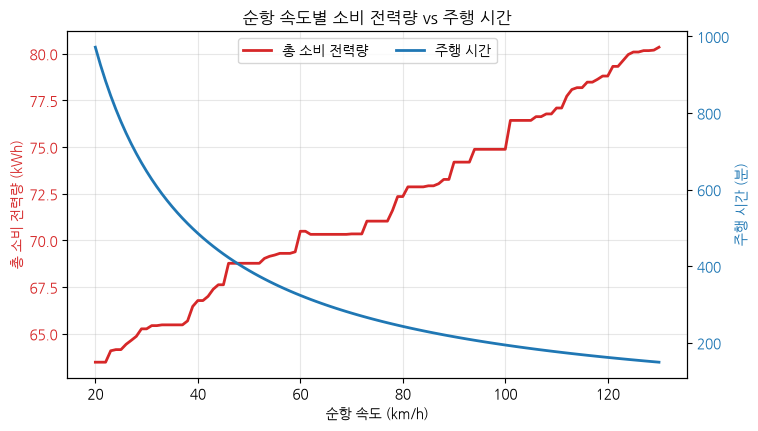

In [255]:
# 속도에 따른 총 소비 전력량과 주행 시간을 한 그래프에서 비교
# 소비 전력과 주행 시간 그래프 

fig, ax_energy = plt.subplots(figsize=(8, 4.5))

ax_energy.plot(profile['speed'], profile['total_energy'],
               color='tab:red', linewidth=2, label='총 소비 전력량')
ax_energy.set_xlabel('순항 속도 (km/h)')
ax_energy.set_ylabel('총 소비 전력량 (kWh)', color='tab:red')
ax_energy.tick_params(axis='y', labelcolor='tab:red')

ax_time = ax_energy.twinx()
ax_time.plot(profile['speed'], profile['travel_time'] * 60,
             color='tab:blue', linewidth=2, label='주행 시간')
ax_time.set_ylabel('주행 시간 (분)', color='tab:blue')
ax_time.tick_params(axis='y', labelcolor='tab:blue')

plt.title('순항 속도별 소비 전력량 vs 주행 시간')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.88), ncol=2)
ax_energy.grid(alpha=0.3)
plt.show()


In [256]:
#  result와 energy_tolerence 입력해주면 에너지 손실주고 속도계산
#  = "최소 전력 대비 N% 까지 더 써도 좋다" 고 허용했을 때 낼 수 있는 가장 빠른 속도
MODE_TOLERANCES = {
    'Eco': 0.10,       # 전력 10% 추가 허용
    'Balanced': 0.15,  # 전력 15% 추가 허용
    'Fast': 0.25,      # 전력 25% 추가 허용
}

base_energy = profile['total_energy'].min()

mode_rows = []
for mode_name, tolerance in MODE_TOLERANCES.items():
    row = select_mode_speed(profile, tolerance)
    mode_rows.append({
        '모드': mode_name,
        '허용 오차': tolerance,
        '추천 속도(km/h)': row['speed'],
        '전비(kWh/100km)': row['consumption_per_100km'],
        '총 소모(kWh)': row['total_energy'],
        '실제 추가 전력(%)': (row['total_energy'] / base_energy - 1) * 100,
        '주행 시간(분)': row['travel_time'] * 60,
    })

mode_table = pd.DataFrame(mode_rows).round(2)

print("=== [모드별 추천 순항 속도] ===")
print(f"기준(최소) 소비 전력 : {base_energy:.2f} kWh")
display(mode_table)


=== [모드별 추천 순항 속도] ===
기준(최소) 소비 전력 : 63.48 kWh


,모드,허용 오차,추천 속도(km/h),전비(kWh/100km),총 소모(kWh),실제 추가 전력(%),주행 시간(분)
0,Eco,0.10,59.0,21.42,69.39,9.31,329.49
1,Balanced,0.15,86.0,22.51,72.93,14.88,226.05
2,Fast,0.25,122.0,24.48,79.32,24.96,159.34


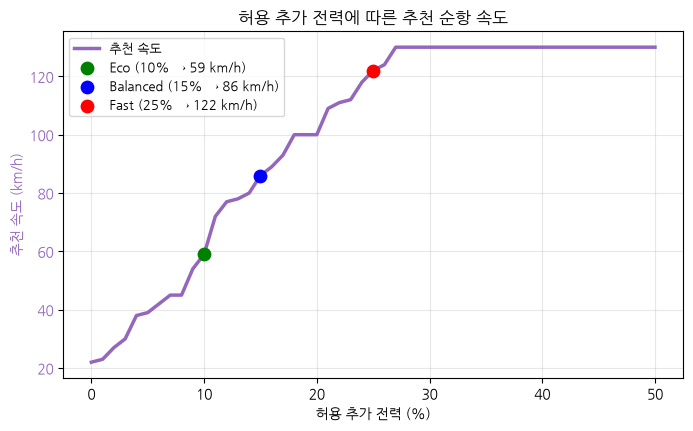

In [257]:
# 허용 오차를 훑으면서 '전력을 더 쓸수록 얼마나 빨라지는지' 확인
tolerance_grid = np.arange(0.0, 0.51, 0.01)

sweep = pd.DataFrame([
    {
        'tolerance': t,
        'speed': select_mode_speed(profile, t)['speed'],
        'travel_time_min': select_mode_speed(profile, t)['travel_time'] * 60,
    }
    for t in tolerance_grid
])

fig, ax_speed = plt.subplots(figsize=(8, 4.5))
ax_speed.plot(sweep['tolerance'] * 100, sweep['speed'],
              color='tab:purple', linewidth=2.5, label='추천 속도')
ax_speed.set_xlabel('허용 추가 전력 (%)')
ax_speed.set_ylabel('추천 속도 (km/h)', color='tab:purple')
ax_speed.tick_params(axis='y', labelcolor='tab:purple')

# 모드별 지점 표시
mode_colors = {'Eco': 'green', 'Balanced': 'blue', 'Fast': 'red'}
for row in mode_rows:
    ax_speed.scatter(
        row['허용 오차'] * 100, row['추천 속도(km/h)'],
        color=mode_colors[row['모드']], s=80, zorder=5,
        label=f"{row['모드']} ({row['허용 오차'] * 100:.0f}% → {row['추천 속도(km/h)']:.0f} km/h)",
    )

plt.title('허용 추가 전력에 따른 추천 순항 속도')
ax_speed.legend(fontsize=9)
ax_speed.grid(alpha=0.3)
plt.show()


## 모델 추출


학습이 끝난 최종 모델(XGBoost)을 파일로 내보내 웹 서비스에서 재사용한다.

- **모델 본체** : `joblib.dump` 로 `model/ev_energy_xgb.pkl` 에 저장.
  sklearn 호환 추정기를 파이썬 객체 그대로 직렬화하므로,
  로드한 뒤 `predict()` 를 노트북에서와 똑같이 호출할 수 있다.
- **메타데이터** : `model/model_meta.json` 에 별도 저장.
  모델 파일만으로는 *어떤 순서로 컬럼을 넣어야 하는지* 를 알 수 없다.
  피처 순서가 어긋나면 예외 없이 조용히 틀린 값을 내놓기 때문에,
  학습 시점의 컬럼 순서·속도 후보 범위·성능 지표를 함께 남긴다.

> joblib 은 파이썬 pickle 기반이라 **라이브러리 버전이 바뀌면 로드가 깨질 수 있다.**
> 그래서 메타에 학습 당시 xgboost / scikit-learn 버전을 기록해 둔다.


In [258]:
import json
from datetime import datetime
from pathlib import Path

import joblib
import sklearn
import xgboost

MODEL_DIR = Path('model')
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / 'ev_energy_xgb.pkl'
META_PATH = MODEL_DIR / 'model_meta.json'

# 1. 최종 선정 모델을 joblib 으로 직렬화
#    compress=3 : 파일 크기와 로드 속도의 절충값 (0 이면 무압축)
joblib.dump(xgb_reg, MODEL_PATH, compress=3)

# 2. 예측 재현에 필요한 부가 정보는 사람이 읽을 수 있게 JSON 으로 따로 남긴다
metadata = {
    'model_file': MODEL_PATH.name,
    'model_type': type(xgb_reg).__name__,
    'serializer': 'joblib',
    'target': 'energy_consumption_kwhper100km',
    # 학습에 쓰인 순서 그대로. 서빙 시 이 순서로 컬럼을 정렬해야 한다.
    'feature_order': list(X_train.columns),
    # predict_speed_profile 이 훑을 후보 속도 (학습 데이터의 speed_kmh 관측 범위)
    'speed_range': [20, 130],
    'speed_step': 1,
    'best_params': xgb_search.best_params_,
    'metrics': {
        'r2': float(r2_score(y_test, xgb_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_test, xgb_pred))),
        'mae': float(mean_absolute_error(y_test, xgb_pred)),
    },
    # joblib 은 pickle 기반이라 버전이 다르면 로드가 실패할 수 있다
    'versions': {
        'xgboost': xgboost.__version__,
        'scikit_learn': sklearn.__version__,
        'joblib': joblib.__version__,
        'pandas': pd.__version__,
        'numpy': np.__version__,
    },
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'n_train_rows': int(len(X_train)),
}

META_PATH.write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False, default=str),
    encoding='utf-8',
)

print("=== [모델 추출 완료] ===")


=== [모델 추출 완료] ===
모델 : model/ev_energy_xgb.pkl  (43.9 KB)
메타 : model/model_meta.json  (0.9 KB)
피처 : ['speed_kmh', 'payload_kg', 'ambient_temp_C', 'hvac_power_kw', 'road_grade_pct', 'battery_temp_C', 'driving_style_index', 'tire_pressure_bar', 'trip_distance_km']
성능 : R2=0.9435, MAE=0.6984


In [259]:
# 3. 저장한 파일을 다시 불러와 원본과 예측이 일치하는지 검증한다.
#    이 검증이 통과해야 웹 서비스에서 노트북과 같은 결과가 나온다.
loaded_model = joblib.load(MODEL_PATH)
loaded_meta = json.loads(META_PATH.read_text(encoding='utf-8'))

# 메타에 적힌 피처 순서로 정렬해서 예측
X_check = X_test[loaded_meta['feature_order']]
reloaded_pred = loaded_model.predict(X_check)

max_diff = float(np.abs(reloaded_pred - xgb_reg.predict(X_check)).max())

print("=== [재로드 검증] ===")
print(f"원본 예측과의 최대 오차 : {max_diff:.10f}")
print(f"동일 여부              : {np.allclose(reloaded_pred, xgb_reg.predict(X_check))}")


=== [재로드 검증] ===
원본 예측과의 최대 오차 : 0.0000000000
동일 여부              : True


#### 모델 서빙 (FastAPI)

추출한 모델은 노트북 밖에서도 그대로 쓰인다.

| 파일 | 역할 |
| --- | --- |
| `ev_recommender.py` | `joblib.load` 로 모델을 올리고, 속도별 전비 프로파일 → 허용 오차 기반 최적 속도 추천 |
| `vehicle_state.py` | 9개 피처 중 사용자가 입력하지 않는 값(센서·경로 정보)을 채우는 계층 |
| `app.py` | FastAPI 엔드포인트 (`/recommend`, `/vehicle`, `/health`) |

```bash
uv run uvicorn app:app --reload
# http://localhost:8000       입력 화면

```

모델은 요청마다 읽지 않고 **서버 기동 시점(lifespan)에 한 번만** 로드한다.
파일이 없거나 버전이 안 맞으면 그 자리에서 기동이 실패하므로,
잘못된 모델로 서비스가 뜨는 상황을 막을 수 있다.
